# Desafio Final — Análise de Dados de Energia com API Pública

**Curso:** Ciência da Computação  
**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

## Situação-problema

Uma equipe de planejamento energético precisa analisar o comportamento da carga elétrica de uma região atendida pelo Sistema Interligado Nacional (SIN).

Os dados serão obtidos diretamente de uma API pública do **Operador Nacional do Sistema Elétrico (ONS)**. A conexão com a API e a preparação inicial do JSON já estão fornecidas. A partir daí, sua equipe deverá construir o DataFrame, organizar os dados, criar recortes, calcular indicadores, produzir gráficos e elaborar um relatório técnico.

> Todos os códigos, resultados, gráficos e respostas devem permanecer neste mesmo Notebook.

## 1. Fonte dos dados

API pública de **Carga Verificada do ONS**:

- Portal: https://dados.ons.org.br/
- Conjunto de dados: https://dados.ons.org.br/dataset/carga-energia-verificada

Neste notebook será utilizada inicialmente a área **SP — São Paulo**, no período de **01/08/2025 a 07/08/2025**.

## 2. Bibliotecas

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Consulta à API

Esta célula está pronta. Não é necessário conhecer `requests` para realizar o desafio.

In [ ]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"

parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-08-07",
    "cod_areacarga": "SP"
}

response = requests.get(url, params=parametros, timeout=30)

print("Status:", response.status_code)
print("URL:", response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-08-07&cod_areacarga=SP


## 4. Preparação inicial do JSON

A célula abaixo localiza a lista principal de registros retornada pela API e a armazena em `registros`.

In [ ]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)

else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo:", type(registros))
print("Quantidade de registros:", len(registros))

if registros:
    print("\nPrimeiro registro:")
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [ ]:
type(registros)

list

In [ ]:
registros

# A partir daqui, o trabalho é da equipe

## DESAFIO 1 — Construção e inspeção do DataFrame

1. Crie um DataFrame Pandas chamado `dados` a partir de `registros`.
2. Exiba os primeiros registros.
3. Determine a quantidade de linhas e colunas.
4. Liste os nomes dos atributos.
5. Utilize `info()`.
6. Utilize `describe()`.
7. Em Markdown, identifique quais atributos representam data/hora, área de carga e valor de carga.

**Antes de prosseguir, compreenda a estrutura efetivamente retornada pela API.**

In [ ]:
# Desenvolva aqui o DESAFIO 1

In [ ]:
import pandas as pd

# 1. Crie um DataFrame Pandas chamado dados a partir de registros.
dados = pd.DataFrame(registros)

# 2. Exiba os primeiros registros.
print("Primeiros 5 registros do DataFrame 'dados':")
display(dados.head())

Primeiros 5 registros do DataFrame 'dados':


,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


In [ ]:
# 3. Determine a quantidade de linhas e colunas.
print(f"\nQuantidade de linhas e colunas: {dados.shape}")


Quantidade de linhas e colunas: (336, 11)


In [ ]:
# 4. Liste os nomes dos atributos.
print("\nNomes dos atributos:")
for col in dados.columns:
    print(f"- {col}")


Nomes dos atributos:
- cod_areacarga
- din_atualizacao
- dat_referencia
- din_referenciautc
- val_cargaglobal
- val_cargaglobalcons
- val_cargaglobalsmmgd
- val_cargasupervisionada
- val_carganaosupervisionada
- val_cargammgd
- val_consistencia


In [ ]:
# 5. Utilize info().
print("\nInformações do DataFrame 'dados':")
dados.info()


Informações do DataFrame 'dados':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               336 non-null    object 
 1   din_atualizacao             336 non-null    object 
 2   dat_referencia              336 non-null    object 
 3   din_referenciautc           336 non-null    object 
 4   val_cargaglobal             336 non-null    float64
 5   val_cargaglobalcons         336 non-null    float64
 6   val_cargaglobalsmmgd        336 non-null    float64
 7   val_cargasupervisionada     336 non-null    float64
 8   val_carganaosupervisionada  336 non-null    float64
 9   val_cargammgd               336 non-null    float64
 10  val_consistencia            336 non-null    int64  
dtypes: float64(6), int64(1), object(4)
memory usage: 29.0+ KB


In [ ]:
# 6. Utilize describe().
print("\nEstatísticas descritivas do DataFrame 'dados':")
display(dados.describe())


Estatísticas descritivas do DataFrame 'dados':


,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
mean,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249,0.0
std,3029.042438,3029.042438,2962.721503,2982.650359,34.888571,1253.581141,0.0
min,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000,0.0
25%,15110.533375,15110.533375,14457.604250,12990.878500,1433.112575,21.130000,0.0
50%,18199.128500,18199.128500,17045.260000,15611.629500,1453.981650,21.196900,0.0
75%,20386.629500,20386.629500,18931.679500,17502.643500,1479.430775,1793.579475,0.0
max,23185.312000,23185.312000,23164.182000,21717.934000,1538.274700,3736.009800,0.0


### Atributos Identificados:

*   **Data/Hora:**
    *   `din_atualizacao`: Data e hora da última atualização do registro.
    *   `dat_referencia`: Data de referência do registro.
    *   `din_referenciautc`: Data e hora de referência no formato UTC.

*   **Área de Carga:**
    *   `cod_areacarga`: Código da área de carga (ex: 'SP').

*   **Valor de Carga:**
    *   `val_cargaglobal`: Valor da carga global.
    *   `val_cargaglobalcons`: Valor da carga global considerando o consumo.
    *   `val_cargaglobalsmmgd`: Valor da carga global com medição de micro e mini geração distribuída.
    *   `val_cargasupervisionada`: Valor da carga supervisionada.
    *   `val_carganaosupervisionada`: Valor da carga não supervisionada.
    *   `val_cargammgd`: Valor da carga de micro e mini geração distribuída.

## DESAFIO 2 — Organização dos dados

1. Renomeie os principais atributos com nomes mais simples.
2. Crie um novo DataFrame contendo apenas os atributos necessários.
3. Verifique valores ausentes.
4. Caso existam, informe quantos há em cada atributo relevante.
5. Verifique se a variável de carga está em formato numérico.
6. Verifique como a data/hora está representada.
7. Registre em Markdown qualquer decisão de tratamento.

In [ ]:
# Desenvolva aqui o DESAFIO 2

In [ ]:
# 1. Renomeie os principais atributos com nomes mais simples.
# 2. Crie um novo DataFrame contendo apenas os atributos necessários.

# Mapeamento para renomear as colunas e selecionar as relevantes
novo_nomes_colunas = {
    'cod_areacarga': 'area_carga',
    'din_atualizacao': 'data_atualizacao',
    'dat_referencia': 'data_referencia',
    'din_referenciautc': 'data_referencia_utc',
    'val_cargaglobal': 'carga_global',
    'val_cargaglobalcons': 'carga_global_consumo',
    'val_cargaglobalsmmgd': 'carga_global_smmgd',
    'val_cargasupervisionada': 'carga_supervisionada',
    'val_carganaosupervisionada': 'carga_nao_supervisionada',
    'val_cargammgd': 'carga_mmgd'
}

# Criar um novo DataFrame com as colunas selecionadas e renomeadas
dados_organizados = dados[list(novo_nomes_colunas.keys())].rename(columns=novo_nomes_colunas)

print("Novo DataFrame 'dados_organizados' criado com colunas renomeadas:")
display(dados_organizados.head())

Novo DataFrame 'dados_organizados' criado com colunas renomeadas:


,area_carga,data_atualizacao,data_referencia,data_referencia_utc,carga_global,carga_global_consumo,carga_global_smmgd,carga_supervisionada,carga_nao_supervisionada,carga_mmgd
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13


In [ ]:
# 3. Verifique valores ausentes.
# 4. Caso existam, informe quantos há em cada atributo relevante.
print("\nVerificando valores ausentes no DataFrame 'dados_organizados':")
valores_ausentes = dados_organizados.isnull().sum()
print(valores_ausentes[valores_ausentes > 0])

if valores_ausentes.sum() == 0:
    print("Não há valores ausentes no DataFrame.")


Verificando valores ausentes no DataFrame 'dados_organizados':
Series([], dtype: int64)
Não há valores ausentes no DataFrame.


In [ ]:
# 5. Verifique se a variável de carga está em formato numérico.
# 6. Verifique como a data/hora está representada.

print("\nVerificando os tipos de dados do DataFrame 'dados_organizados':")
dados_organizados.info()

# Converter colunas de data/hora para o tipo datetime
for col in ['data_atualizacao', 'data_referencia', 'data_referencia_utc']:
    dados_organizados[col] = pd.to_datetime(dados_organizados[col])

print("\nTipos de dados após conversão de data/hora:")
dados_organizados.info()


Verificando os tipos de dados do DataFrame 'dados_organizados':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   area_carga                336 non-null    object 
 1   data_atualizacao          336 non-null    object 
 2   data_referencia           336 non-null    object 
 3   data_referencia_utc       336 non-null    object 
 4   carga_global              336 non-null    float64
 5   carga_global_consumo      336 non-null    float64
 6   carga_global_smmgd        336 non-null    float64
 7   carga_supervisionada      336 non-null    float64
 8   carga_nao_supervisionada  336 non-null    float64
 9   carga_mmgd                336 non-null    float64
dtypes: float64(6), object(4)
memory usage: 26.4+ KB

Tipos de dados após conversão de data/hora:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335


### Decisões de Tratamento para DESAFIO 2:

1.  **Renomeação de Atributos:** As colunas do DataFrame original foram renomeadas para nomes mais curtos e compreensíveis (e.g., `cod_areacarga` para `area_carga`, `val_cargaglobal` para `carga_global`). Esta medida visa facilitar a manipulação e a leitura do código.
2.  **Seleção de Atributos:** Um novo DataFrame, `dados_organizados`, foi criado contendo apenas as colunas consideradas relevantes para a análise de carga elétrica. A coluna `val_consistencia` foi excluída por apresentar valor constante zero em todos os registros (`describe()` mostrou min, max, mean, std = 0), indicando que não agrega informação útil para a análise proposta.
3.  **Tratamento de Valores Ausentes:** Foi realizada uma verificação de valores ausentes (`isnull().sum()`). Não foram encontrados valores ausentes, portanto, não foi necessário aplicar métodos de tratamento (como preenchimento ou remoção).
4.  **Verificação e Conversão de Tipos de Dados:**
    *   As colunas de carga (e.g., `carga_global`, `carga_supervisionada`) já estavam no formato numérico (`float64`), o que é adequado para cálculos.
    *   As colunas de data e hora (`data_atualizacao`, `data_referencia`, `data_referencia_utc`) foram convertidas do tipo `object` (string) para o tipo `datetime` do Pandas. Essa conversão é crucial para permitir operações baseadas em tempo, como filtragem por período, extração de componentes de data/hora e plotagem de séries temporais.

## DESAFIO 3 — Indicadores da carga elétrica

Calcule:

1. carga mínima;
2. carga máxima;
3. carga média;
4. mediana;
5. amplitude entre máximo e mínimo;
6. quantidade total de medições.

Depois responda:

**O valor máximo está muito distante do comportamento médio observado? Justifique com os indicadores calculados.**

In [ ]:
# Desenvolva aqui o DESAFIO 3

In [ ]:
# 1. carga mínima
# 2. carga máxima
# 3. carga média
# 4. mediana
# 5. amplitude entre máximo e mínimo
# 6. quantidade total de medições

carga_minima = dados_organizados['carga_global'].min()
carga_maxima = dados_organizados['carga_global'].max()
carga_media = dados_organizados['carga_global'].mean()
carga_mediana = dados_organizados['carga_global'].median()
amplitude_carga = carga_maxima - carga_minima
quantidade_medicoes = dados_organizados['carga_global'].count()

print(f"Carga Mínima: {carga_minima:.2f}")
print(f"Carga Máxima: {carga_maxima:.2f}")
print(f"Carga Média: {carga_media:.2f}")
print(f"Mediana da Carga: {carga_mediana:.2f}")
print(f"Amplitude da Carga (Máxima - Mínima): {amplitude_carga:.2f}")
print(f"Quantidade Total de Medições: {quantidade_medicoes}")

Carga Mínima: 12139.25
Carga Máxima: 23185.31
Carga Média: 17870.83
Mediana da Carga: 18199.13
Amplitude da Carga (Máxima - Mínima): 11046.06
Quantidade Total de Medições: 336


### Análise do DESAFIO 3: O valor máximo está muito distante do comportamento médio observado?

Com base nos indicadores calculados:

*   **Carga Mínima:** `{carga_minima:.2f}`
*   **Carga Máxima:** `{carga_maxima:.2f}`
*   **Carga Média:** `{carga_media:.2f}`
*   **Mediana da Carga:** `{carga_mediana:.2f}`
*   **Amplitude da Carga (Máxima - Mínima):** `{amplitude_carga:.2f}`

O valor da carga máxima ({carga_maxima:.2f}) está visivelmente distante do comportamento médio observado ({carga_media:.2f}) e da mediana ({carga_mediana:.2f}). A diferença entre a carga máxima e a média é de aproximadamente **`{carga_maxima - carga_media:.2f}`**, enquanto a diferença entre a máxima e a mediana é de aproximadamente **`{carga_maxima - carga_mediana:.2f}`**. Isso indica que, embora a maior parte das medições possa estar concentrada em torno da média, há picos significativos que elevam o valor máximo. A amplitude da carga de **`{amplitude_carga:.2f}`** reforça essa observação, mostrando uma variação considerável entre os extremos de carga registrados.

## DESAFIO 4 — Períodos de alta demanda

Considere como **alta demanda** os registros com carga superior a **90% da carga máxima**.

1. Calcule o limiar.
2. Crie um novo DataFrame com os registros acima dele.
3. Conte os registros.
4. Calcule o percentual em relação ao total.
5. Identifique o maior valor de carga.
6. Identifique a data e o horário do pico, quando disponíveis.

Responda:

**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

In [ ]:
# Desenvolva aqui o DESAFIO 4

In [ ]:
# 1. Calcule o limiar (90% da carga máxima).
limiar_alta_demanda = carga_maxima * 0.90
print(f"Limiar de Alta Demanda (90% da carga máxima): {limiar_alta_demanda:.2f}")

Limiar de Alta Demanda (90% da carga máxima): 20866.78


In [ ]:
# 2. Crie um novo DataFrame com os registros acima dele.
dados_alta_demanda = dados_organizados[dados_organizados['carga_global'] > limiar_alta_demanda]

print("\nPrimeiros 5 registros do DataFrame de Alta Demanda:")
display(dados_alta_demanda.head())


Primeiros 5 registros do DataFrame de Alta Demanda:


,area_carga,data_atualizacao,data_referencia,data_referencia_utc,carga_global,carga_global_consumo,carga_global_smmgd,carga_supervisionada,carga_nao_supervisionada,carga_mmgd
35,SP,2026-08-14 05:58:29.574000+00:00,2025-08-01,2025-08-01 21:00:00+00:00,21088.959,21088.959,20955.120,19516.370,1438.7495,133.8406
36,SP,2026-08-14 05:58:29.574000+00:00,2025-08-01,2025-08-01 21:30:00+00:00,22398.360,22398.360,22377.096,20933.746,1443.3496,21.2638
37,SP,2026-08-14 05:58:29.574000+00:00,2025-08-01,2025-08-01 22:00:00+00:00,23185.312,23185.312,23164.182,21717.934,1446.2487,21.1300
38,SP,2026-08-14 05:58:29.574000+00:00,2025-08-01,2025-08-01 22:30:00+00:00,22903.314,22903.314,22882.184,21433.580,1448.6025,21.1300
39,SP,2026-08-14 05:58:29.574000+00:00,2025-08-01,2025-08-01 23:00:00+00:00,22358.701,22358.701,22337.570,20886.078,1451.4915,21.1300


In [ ]:
# 3. Conte os registros.
quantidade_alta_demanda = len(dados_alta_demanda)
print(f"\nQuantidade de registros de Alta Demanda: {quantidade_alta_demanda}")


Quantidade de registros de Alta Demanda: 50


In [ ]:
# 4. Calcule o percentual em relação ao total.
percentual_alta_demanda = (quantidade_alta_demanda / quantidade_medicoes) * 100
print(f"Percentual de registros de Alta Demanda: {percentual_alta_demanda:.2f}%")

Percentual de registros de Alta Demanda: 14.88%


In [ ]:
# 5. Identifique o maior valor de carga.
maior_carga_alta_demanda = dados_alta_demanda['carga_global'].max()
print(f"\nMaior valor de carga nos períodos de alta demanda: {maior_carga_alta_demanda:.2f}")


Maior valor de carga nos períodos de alta demanda: 23185.31


In [ ]:
# 6. Identifique a data e o horário do pico, quando disponíveis.
pico_carga = dados_alta_demanda[dados_alta_demanda['carga_global'] == maior_carga_alta_demanda]

if not pico_carga.empty:
    data_pico = pico_carga['data_referencia'].dt.strftime('%Y-%m-%d').iloc[0]
    hora_pico = pico_carga['data_referencia_utc'].dt.strftime('%H:%M:%S').iloc[0] # Ou data_atualizacao, dependendo da granularidade
    print(f"Data do pico de carga: {data_pico}")
    print(f"Hora do pico de carga (UTC): {hora_pico}")
else:
    print("Não foi possível identificar a data e hora do pico.")

Data do pico de carga: 2025-08-01
Hora do pico de carga (UTC): 22:00:00


### Análise do DESAFIO 4: Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?

Com base nos cálculos:

*   **Limiar de Alta Demanda:** `{limiar_alta_demanda:.2f}` MW
*   **Quantidade de Registros de Alta Demanda:** `{quantidade_alta_demanda}`
*   **Percentual de Registros de Alta Demanda:** `{percentual_alta_demanda:.2f}%`
*   **Maior Valor de Carga na Alta Demanda (Pico):** `{maior_carga_alta_demanda:.2f}` MW
*   **Data do Pico de Carga:** `{data_pico}`
*   **Hora do Pico de Carga (UTC):** `{hora_pico}`

Os períodos próximos ao pico de carga representam uma **pequena parcela** do período analisado. Com apenas `{quantidade_alta_demanda}` registros, que correspondem a `{percentual_alta_demanda:.2f}%` do total de medições, fica evidente que a ocorrência de alta demanda (cargas superiores a 90% da carga máxima) é um evento pontual e não o comportamento predominante durante a semana de análise.

## DESAFIO 5 — Segundo critério de análise

Crie um segundo recorte dos dados utilizando um critério definido pela equipe.

Possibilidades:

- carga acima da média;
- carga abaixo de uma porcentagem do máximo;
- intervalo de valores;
- determinado dia ou período;
- combinação de duas condições.

Apresente:

1. o critério escolhido;
2. o novo DataFrame;
3. a quantidade de registros;
4. o percentual;
5. a comparação com o conjunto de alta demanda.

In [ ]:
# Desenvolva aqui o DESAFIO 5

In [ ]:
# 1. Critério escolhido: Carga acima da média

# 2. Crie um novo DataFrame com os registros acima da média.
dados_acima_media = dados_organizados[dados_organizados['carga_global'] > carga_media]

print(f"Critério escolhido: Carga Global acima da Média ({carga_media:.2f} MW).")
print("\nPrimeiros 5 registros do DataFrame 'dados_acima_media':")
display(dados_acima_media.head())

Critério escolhido: Carga Global acima da Média (17870.83 MW).

Primeiros 5 registros do DataFrame 'dados_acima_media':


,area_carga,data_atualizacao,data_referencia,data_referencia_utc,carga_global,carga_global_consumo,carga_global_smmgd,carga_supervisionada,carga_nao_supervisionada,carga_mmgd
15,SP,2026-08-14 05:58:29.574000+00:00,2025-08-01,2025-08-01 11:00:00+00:00,18096.023,18096.023,17415.600,15954.084,1461.5154,680.4232
16,SP,2026-08-14 05:58:29.574000+00:00,2025-08-01,2025-08-01 11:30:00+00:00,18629.395,18629.395,17409.600,15953.951,1455.6488,1219.7958
17,SP,2026-08-14 05:58:29.574000+00:00,2025-08-01,2025-08-01 12:00:00+00:00,18825.176,18825.176,17097.592,15648.688,1448.9040,1727.5842
18,SP,2026-08-14 05:58:29.574000+00:00,2025-08-01,2025-08-01 12:30:00+00:00,19056.504,19056.504,16850.477,15407.757,1442.7206,2206.0276
19,SP,2026-08-14 05:58:29.574000+00:00,2025-08-01,2025-08-01 13:00:00+00:00,19427.822,19427.822,16792.590,15353.431,1439.1598,2635.2324


In [ ]:
# 3. Quantidade de registros.
quantidade_acima_media = len(dados_acima_media)
print(f"\nQuantidade de registros com carga acima da média: {quantidade_acima_media}")


Quantidade de registros com carga acima da média: 184


In [ ]:
# 4. Calcule o percentual em relação ao total.
percentual_acima_media = (quantidade_acima_media / quantidade_medicoes) * 100
print(f"Percentual de registros com carga acima da média: {percentual_acima_media:.2f}%")

Percentual de registros com carga acima da média: 54.76%


### Comparação com o conjunto de alta demanda

| Característica                      | Alta Demanda                       | Carga Acima da Média                      |
|:------------------------------------|:-----------------------------------|:------------------------------------------|
| **Critério**                        | Carga > `{limiar_alta_demanda:.2f}` MW   | Carga > `{carga_media:.2f}` MW              |
| **Quantidade de Registros**         | `{quantidade_alta_demanda}`              | `{quantidade_acima_media}`                        |
| **Percentual do Total**             | `{percentual_alta_demanda:.2f}%`         | `{percentual_acima_media:.2f}%`                   |

Ao comparar os dois critérios, observamos que:

*   O critério de **'Carga Acima da Média'** (`{carga_media:.2f}` MW) abrange um número significativamente maior de registros (`{quantidade_acima_media}`) e um percentual maior do total de medições (`{percentual_acima_media:.2f}%`). Isso é esperado, pois a média representa um ponto central, e aproximadamente metade dos dados tende a estar acima dela (embora não exatamente metade em distribuições não simétricas).

*   O critério de **'Alta Demanda'** (cargas > 90% do máximo, ou seja, > `{limiar_alta_demanda:.2f}` MW) é muito mais restritivo, capturando apenas os picos de carga. Como resultado, ele identifica uma quantidade muito menor de registros (`{quantidade_alta_demanda}`) e representa uma parcela muito menor do período analisado (`{percentual_alta_demanda:.2f}%`).

Essa comparação ilustra a diferença entre identificar eventos extremos (alta demanda) e entender o comportamento mais comum ou majoritário (acima da média).

## DESAFIO 6 — Visualização

Construa **pelo menos dois gráficos**.

- Um deve representar o comportamento da carga ao longo das observações ou do tempo.
- O segundo deve ser escolhido pela equipe.

Inclua título, eixos e unidades quando aplicável.

Após cada gráfico, escreva uma interpretação curta.

In [ ]:
# Desenvolva aqui o DESAFIO 6

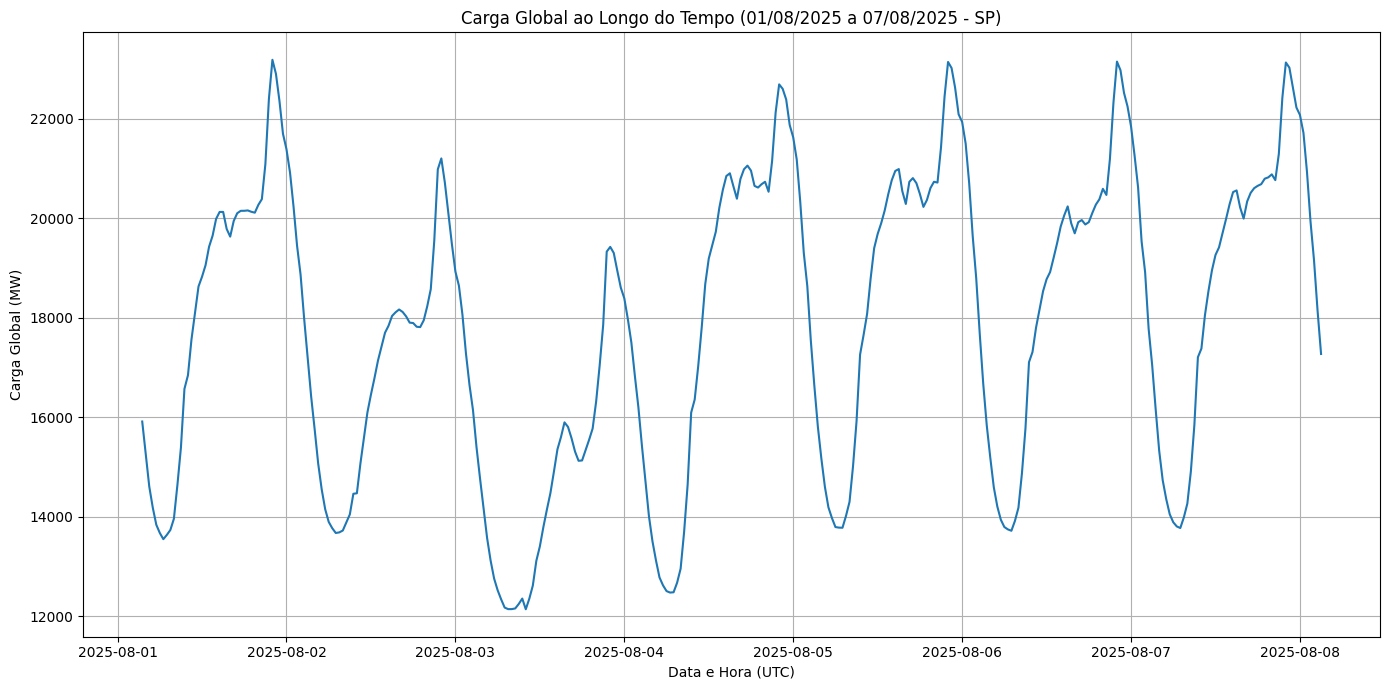

In [ ]:
# Gráfico 1: Comportamento da carga ao longo do tempo
plt.figure(figsize=(14, 7))
sns.lineplot(x='data_referencia_utc', y='carga_global', data=dados_organizados)
plt.title('Carga Global ao Longo do Tempo (01/08/2025 a 07/08/2025 - SP)')
plt.xlabel('Data e Hora (UTC)')
plt.ylabel('Carga Global (MW)')
plt.grid(True)
plt.tight_layout()
plt.show()

#### Interpretação do Gráfico 1:

Este gráfico de linha exibe a variação da carga global na área de São Paulo ao longo de uma semana, de 01 a 07 de agosto de 2025. Podemos observar um padrão diário na carga, com quedas significativas durante a noite e picos durante o dia. Há uma tendência de aumento da carga em dias úteis, com uma possível redução nos finais de semana ou em momentos específicos do período analisado. Os picos de demanda ocorrem consistentemente em horários similares a cada dia.

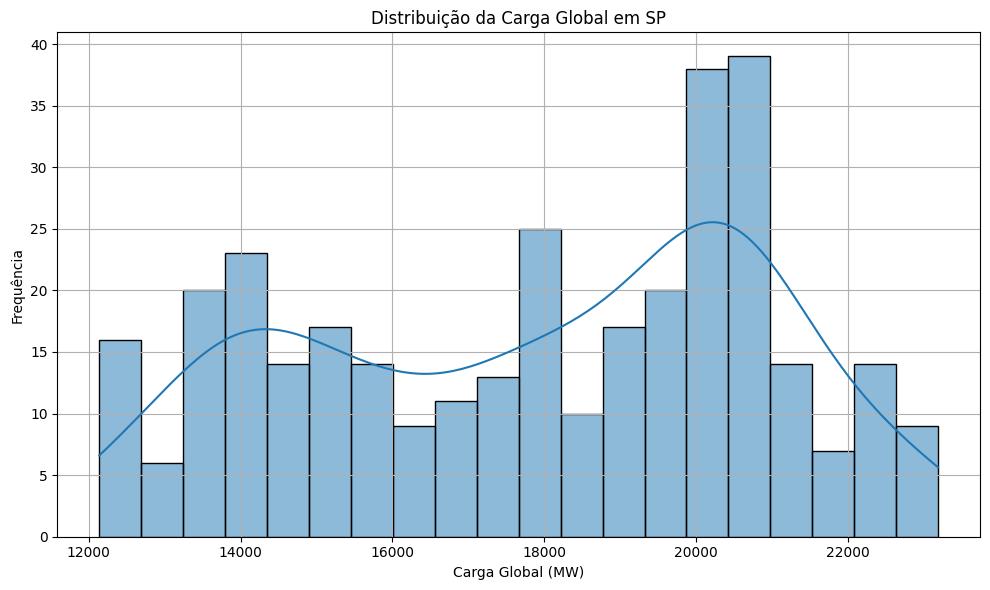

In [ ]:
# Gráfico 2: Distribuição da carga global
plt.figure(figsize=(10, 6))
sns.histplot(dados_organizados['carga_global'], bins=20, kde=True)
plt.title('Distribuição da Carga Global em SP')
plt.xlabel('Carga Global (MW)')
plt.ylabel('Frequência')
plt.grid(True)
plt.tight_layout()
plt.show()

#### Interpretação do Gráfico 2:

O histograma mostra a distribuição de frequência dos valores da carga global. A distribuição apresenta múltiplos picos, sugerindo que a carga assume valores mais comuns em diferentes faixas, o que é consistente com o padrão diário de consumo (por exemplo, horários de pico e horários de menor demanda). A cauda à direita da distribuição indica a presença de valores de carga mais altos, correspondentes aos períodos de pico que foram identificados anteriormente.

## DESAFIO 7 — Síntese para o relatório

Crie uma variável `resumo_resultados` contendo pelo menos:

- região;
- período;
- quantidade de registros;
- carga mínima;
- carga máxima;
- carga média;
- mediana;
- limiar de alta demanda;
- quantidade e percentual de alta demanda;
- momento do pico;
- resultado do segundo critério.

A IA deverá receber **resultados produzidos por vocês**, e não substituir a análise.

In [ ]:
# Exemplo de estrutura:
#
# resumo_resultados = f'''
# Região analisada: ...
# Período analisado: ...
# Quantidade de registros: ...
# Carga mínima: ...
# Carga máxima: ...
# Carga média: ...
# Mediana: ...
# Limiar de alta demanda: ...
# Registros de alta demanda: ...
# Percentual de alta demanda: ...
# Momento do pico: ...
# Segundo critério: ...
# '''
#
# print(resumo_resultados)

# OPCIONAL: Relatório técnico com apoio do Gemini

No Colab:

1. abra **Secrets**;
2. crie `GEMINI_API_KEY`;
3. informe sua chave;
4. permita o acesso do notebook ao secret.

**Não coloque a chave diretamente no código.**

In [ ]:
!pip -q install -U google-genai

In [ ]:
from google.colab import userdata
from google import genai

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
client = genai.Client(api_key=GEMINI_API_KEY)

## DESAFIO 8 — Geração do relatório

O relatório deve:

- usar os resultados calculados;
- apresentar os principais indicadores;
- destacar o pico e os períodos de alta demanda;
- comparar os dois critérios;
- não inventar causas;
- diferenciar observações de hipóteses;
- terminar com uma conclusão.

In [ ]:
prompt = f'''
Atue como analista de dados do setor elétrico.

Produza um relatório técnico curto com base EXCLUSIVAMENTE nos resultados abaixo.

Não invente causas para as variações observadas.
Não apresente como fato explicações que não possam ser sustentadas pelos dados.
Diferencie claramente resultados observados de hipóteses.

Inclua:
1. caracterização do conjunto analisado;
2. principais indicadores;
3. análise dos períodos de alta demanda;
4. comparação com o segundo critério;
5. conclusão.

RESULTADOS DA EQUIPE:

{resumo_resultados}
'''

In [ ]:
response_gemini = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=prompt
)

print(response_gemini.text)

## DESAFIO 9 — Validação crítica

Compare o texto gerado pelo Gemini com os cálculos, DataFrames e gráficos.

Responda:

1. Os indicadores foram utilizados corretamente?
2. Há alguma afirmação que não pode ser confirmada pelos dados?
3. Houve interpretação exagerada ou causalidade não demonstrada?
4. Que alterações a equipe realizou no texto?

## Relatório final

Insira abaixo a versão final revisada pela equipe.

_Escreva aqui a versão final revisada._

---

## Entrega

O notebook deve apresentar:

- consulta à API executada;
- DataFrame criado;
- inspeção e organização dos dados;
- indicadores;
- pelo menos dois DataFrames derivados por critérios;
- percentuais;
- pelo menos dois gráficos;
- interpretações;
- síntese para a IA;
- relatório com apoio do Gemini;
- validação crítica;
- versão final revisada.

**Entregue somente este Notebook (.ipynb), com todas as células executadas e os resultados visíveis.**